# Bootstrap Explained

---

## 1. The Question Bootstrap Answers

Imagine you measure the height of **5 students** in your class:

```
[170, 165, 180, 172, 168] cm
```

The average is **171 cm**. But that average has a problem: if you had measured **5 other different students**, you would have obtained a different average. Maybe 169, maybe 173.

**The key question:** How reliable is that 171? How much could it vary if you repeated the experiment?

The problem is that **we only have one sample** and we can't go out and measure more students. This is where Bootstrap comes in.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Our single sample: 5 heights in cm
sample = np.array([170, 165, 180, 172, 168])

print(f'Sample: {sample}')
print(f'Size (n): {len(sample)}')
print(f'Mean: {sample.mean():.2f} cm')
print(f'Standard deviation: {sample.std():.2f} cm')

Sample: [170 165 180 172 168]
Size (n): 5
Mean: 171.00 cm
Standard deviation: 5.06 cm


---

## 2. The Brilliant Bootstrap Trick

**"Treat your sample as if it were the entire population, and sample with replacement."**

**"With replacement"** means that after choosing a value, you return it to the pool, and it can appear again in the same resample.

Let's see what **a single resample** looks like:

In [2]:
# We generate a resample: we take 5 random values ​​WITH REPLACEMENT from the sample
np.random.seed(42) # so that the example is reproducible

resample = np.random.choice(sample, size=5, replace=True)

print(f'Original sample: {sample}')
print(f'A resample: {resample}')
print(f'Resample mean: {resample.mean():.2f} cm')
print()
print('Notice that:')
print('- Some values ​​appear more than once')
print('- Other values ​​do not appear at all')
print('- This is PRECISELY what "with replacement" means')

Original sample: [170 165 180 172 168]
A resample: [172 168 180 168 168]
Resample mean: 171.20 cm

Notice that:
- Some values ​​appear more than once
- Other values ​​do not appear at all
- This is PRECISELY what "with replacement" means


### Generating Multiple Resamples

Each time we call `np.random.choice(..., replace=True)`, we get a different resample. Let's generate 10 and see their averages:

In [4]:
np.random.seed(42)

print(f'{"#":<4}{"Resample":<30}{"Average":<10}')
print('-' * 50)
for i in range(10): 
    resample = np.random.choice(sample, size=5, replace=True) 
    print(f'{i+1:<4}{str(resample):<30}{resample.mean():<10.2f}')

#   Resample                      Average   
--------------------------------------------------
1   [172 168 180 168 168]         171.20    
2   [165 180 180 180 168]         174.60    
3   [172 180 168 165 172]         171.40    
4   [165 172 168 170 172]         169.40    
5   [165 168 172 170 170]         169.00    
6   [180 180 165 172 172]         173.80    
7   [180 172 172 170 180]         174.80    
8   [168 180 168 170 165]         170.20    
9   [172 170 172 165 165]         168.80    
10  [170 165 168 165 172]         168.00    


**Note that each resample produces a different mean.** That variation is exactly the information we want to capture.

---

## 3. Bootstrap manual: 10,000 resamples

Now let's do it on a larger scale: we generate **10,000 resamples** and save the average of each one. This is exactly what `scipy.stats.bootstrap` does under the hood.

In [5]:
np.random.seed(42)

n_resamples = 10_000
bootstrap_means = []

for _ in range(n_resamples):
    resample = np.random.choice(sample, size=len(sample), replace=True)
    bootstrap_means.append(resample.mean())

bootstrap_means = np.array(bootstrap_means)

print(f'Total generated means:      {len(bootstrap_means):,}')
print(f'First 10 means:             {bootstrap_means[:10].round(2)}')
print()
print(f'Mean of ALL means:          {bootstrap_means.mean():.2f}  (close to the original: {sample.mean():.2f})')
print(f'Standard deviation of means:{bootstrap_means.std():.2f}  <- THIS is the "standard error"')

Total generated means:      10,000
First 10 means:             [171.2 174.6 171.4 169.4 169.  173.8 174.8 170.2 168.8 168. ]

Mean of ALL means:          170.95  (close to the original: 171.00)
Standard deviation of means:2.20  <- THIS is the "standard error"


### Visualizing the Bootstrap Distribution

This is where Bootstrap becomes clearer. These 10,000 averages form a distribution that tells us how the statistic varies:

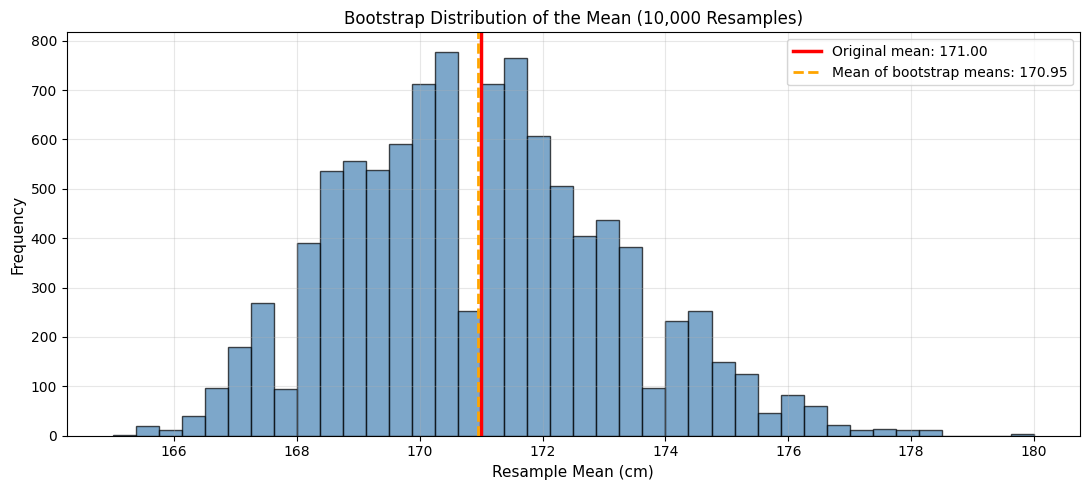

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(bootstrap_means, bins=40, edgecolor='black', alpha=0.7, color='steelblue')

ax.axvline(
    sample.mean(),
    color='red',
    linewidth=2.5,
    linestyle='-',
    label=f'Original mean: {sample.mean():.2f}'
)

ax.axvline(
    bootstrap_means.mean(),
    color='orange',
    linewidth=2,
    linestyle='--',
    label=f'Mean of bootstrap means: {bootstrap_means.mean():.2f}'
)

ax.set_xlabel('Resample Mean (cm)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Bootstrap Distribution of the Mean (10,000 Resamples)', fontsize=12)

ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What we're seeing:**

- The histogram shows **how the mean changes** when we resample.
- Most of the means fall close to the original value (171), but some are higher and some are lower.
- The **width of this distribution** tells us how much uncertainty there is in our estimate.

---

## 4. Building the Confidence Interval

We already have the bootstrap distribution. To construct a **95% confidence interval**, we simply take the **2.5th and 97.5th percentiles** of the 10,000 means.

That means: we discard the lowest 2.5% and the highest 2.5%, and the range of the central 95% is our interval.

In [7]:
# Calculate the percentiles
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)

print(' 95% Confidence Interval '.center(50, "="))
print(f'  Lower bound (2.5th percentile):  {ci_lower:.2f} cm')
print(f'  Point estimate (mean):           {sample.mean():.2f} cm')
print(f'  Upper bound (97.5th percentile): {ci_upper:.2f} cm')

print()
print('In other words, with 95% confidence,')
print(f'the true mean is between {ci_lower:.2f} and {ci_upper:.2f} cm.')

============ 95% Confidence Interval =============
  Lower bound (2.5th percentile):  167.00 cm
  Point estimate (mean):           171.00 cm
  Upper bound (97.5th percentile): 175.60 cm

In other words, with 95% confidence,
the true mean is between 167.00 and 175.60 cm.


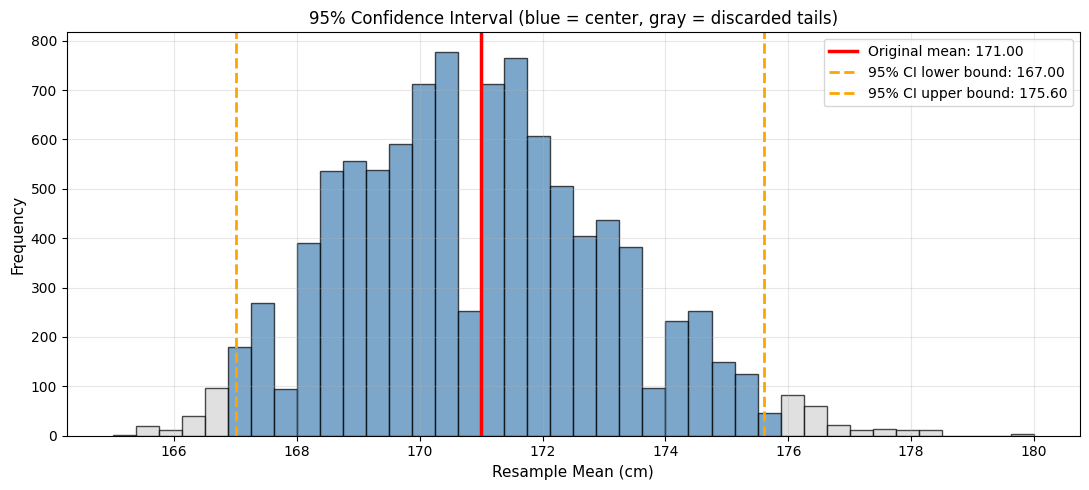

In [8]:
# Visualize the confidence interval on the histogram
fig, ax = plt.subplots(figsize=(11, 5))

# Color the tails differently (discarded areas) and the center (95% CI)
n, bins, patches = ax.hist(
    bootstrap_means,
    bins=40,
    edgecolor='black',
    alpha=0.7
)

for i, (left, right) in enumerate(zip(bins[:-1], bins[1:])):
    if right < ci_lower or left > ci_upper:
        patches[i].set_facecolor('lightgray')  # tail: discarded area
    else:
        patches[i].set_facecolor('steelblue')  # center: 95% CI

ax.axvline(
    sample.mean(),
    color='red',
    linewidth=2.5,
    label=f'Original mean: {sample.mean():.2f}'
)

ax.axvline(
    ci_lower,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'95% CI lower bound: {ci_lower:.2f}'
)

ax.axvline(
    ci_upper,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'95% CI upper bound: {ci_upper:.2f}'
)

ax.set_xlabel('Resample Mean (cm)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)

ax.set_title(
    '95% Confidence Interval (blue = center, gray = discarded tails)',
    fontsize=12
)

ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()